# Dike Guidance Demo 近期工作总览 Notebook

本 notebook 用于把近期 dike guidance demo 相关工作整合到一个可展示入口：

- 汇总新增代码模块的位置、设计思路和目的；
- 读取已有 `csv/json/png` 结果，不触发训练，不默认启动长时间采样；
- 展示 `label9`、`label10`、`label7` 三个重点 case 的 gravity-only 结果和关键图片；
- 展示 magnetic-proxy / gravity-gradient-proxy 扩展后的诊断结果；
- 给出目前应如何解释这些结果的结论。

当前总体判断：**gravity-only lightweight proxy guidance 有弱正向证据；magnetic / gravity-gradient 扩展当前没有达到论文 Demo 预期。**

## 1. 路径与读取工具

本单元只读取已有结果文件，不触发采样、不触发训练。路径按 notebook 所在目录解析。

In [1]:
from pathlib import Path
import csv
import json
import math

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from IPython.display import display, Markdown, HTML, Code
except Exception:
    display = print
    Markdown = str
    HTML = str
    Code = None

BASE = Path.cwd()
if BASE.name != "dike-demo-manual":
    candidate = Path("flowtrain_stochastic_interpolation-main/project/geodata-3d-conditional/dike-demo-manual")
    if candidate.exists():
        BASE = candidate
PROJECT = BASE.parent

print("BASE =", BASE.resolve())
print("PROJECT =", PROJECT.resolve())

def read_csv_rows(path):
    path = Path(path)
    if not path.exists():
        return []
    with path.open(newline="", encoding="utf-8") as stream:
        return list(csv.DictReader(stream))

def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))

def finite_values(rows, column):
    values = []
    for row in rows:
        try:
            value = float(row.get(column, "nan"))
        except Exception:
            continue
        if math.isfinite(value):
            values.append(value)
    return values

def mean_value(rows, column):
    values = finite_values(rows, column)
    return sum(values) / len(values) if values else None

def stats(rows, column):
    values = finite_values(rows, column)
    if not values:
        return None
    return {
        "n": len(values),
        "mean": sum(values) / len(values),
        "min": min(values),
        "max": max(values),
    }

def show_table(rows):
    if pd is not None:
        display(pd.DataFrame(rows))
    else:
        for row in rows:
            print(row)

def fmt(value, digits=5):
    if value is None or value == "":
        return None
    return round(float(value), digits)

def rel(path):
    path = Path(path)
    try:
        return path.relative_to(BASE)
    except ValueError:
        try:
            return path.relative_to(PROJECT)
        except ValueError:
            return path

def show_image_grid(items, width=360):
    """Display existing images as a compact HTML grid.

    items: sequence of (title, path) tuples. Missing files are listed but skipped.
    """
    cards = []
    missing = []
    for title, path in items:
        path = Path(path)
        if not path.exists():
            missing.append(f"{title}: {path}")
            continue
        src = rel(path).as_posix()
        cards.append(
            f"""
            <div style='display:inline-block; vertical-align:top; margin:8px; width:{width}px;'>
              <div style='font-weight:600; margin-bottom:4px'>{title}</div>
              <img src='{src}' style='max-width:{width}px; border:1px solid #ddd'>
              <div style='font-size:11px; color:#666; word-break:break-all'>{src}</div>
            </div>
            """
        )
    if cards:
        display(HTML("\n".join(cards)))
    if missing:
        display(Markdown("**缺失图片：**\n" + "\n".join(f"- `{item}`" for item in missing)))

def show_code(path, start_text=None, end_text=None, max_lines=90):
    """Display a source-code snippet from a project file."""
    path = Path(path)
    text = path.read_text(encoding="utf-8")
    lines = text.splitlines()
    start = 0
    if start_text:
        for i, line in enumerate(lines):
            if start_text in line:
                start = i
                break
    end = min(len(lines), start + max_lines)
    if end_text:
        for i in range(start + 1, len(lines)):
            if end_text in lines[i]:
                end = i
                break
    snippet = "\n".join(f"{i + 1:4d}: {line}" for i, line in enumerate(lines[start:end], start=start))
    display(Markdown(f"**{rel(path)}**"))
    if Code is not None:
        display(Code(snippet, language="python"))
    else:
        print(snippet)


def md_link(path, label=None):
    path = Path(path)
    label = label or path.name
    return f"[{label}]({rel(path).as_posix()})"

CASE_DEMOS = {
    "label9 / cond_generation_0": {
        "target_label": 9,
        "case_dir": BASE / "cond_generation_0_label9/final_demo",
        "truth_gallery_dir": BASE / "all_truth_3d/cond_generation_0",
        "target_3d": BASE / "cond_generation_0_label9/final_demo/truth_label_qa/label_3d/label_9_3d.png",
    },
    "label10 / cond_generation_1": {
        "target_label": 10,
        "case_dir": BASE / "candidate_screening/cond_generation_1_label10/final_demo",
        "truth_gallery_dir": BASE / "all_truth_3d/cond_generation_1",
        "target_3d": BASE / "candidate_screening/cond_generation_1_label10/final_demo/truth_label_qa/label_3d/label_10_3d.png",
    },
    "label7 / paper_cond_gen_0": {
        "target_label": 7,
        "case_dir": BASE / "candidate_screening/paper_cond_gen_0_label7/final_demo",
        "truth_gallery_dir": BASE / "all_truth_3d/paper_cond_gen_0",
        "target_3d": BASE / "candidate_screening/paper_cond_gen_0_label7/final_demo/truth_label_qa/label_3d/label_7_3d.png",
    },
}

def case_metric_summary(case_dir):
    baseline_global = read_csv_rows(case_dir / "baseline_global_evaluation/metrics.csv") or read_csv_rows(case_dir / "input_baseline_metrics.csv")
    guided_global = read_csv_rows(case_dir / "guided_global_evaluation/metrics.csv") or read_csv_rows(case_dir / "input_guided_metrics.csv")
    baseline_target = read_csv_rows(case_dir / "baseline_target/target_metrics.csv")
    guided_target = read_csv_rows(case_dir / "guided_target/target_metrics.csv")
    residual = read_json(case_dir / "residuals/summary.json")
    manifest = read_json(case_dir / "manifest.json")
    return {
        "target_label": manifest.get("target_label"),
        "paired_by_seed": manifest.get("paired_by_seed"),
        "baseline_geo": mean_value(baseline_global, "geo_misfit"),
        "guided_geo": mean_value(guided_global, "geo_misfit"),
        "baseline_target_iou": mean_value(baseline_target, "target_iou"),
        "guided_target_iou": mean_value(guided_target, "target_iou"),
        "baseline_target_f1": mean_value(baseline_target, "target_f1"),
        "guided_target_f1": mean_value(guided_target, "target_f1"),
        "baseline_recall": mean_value(baseline_target, "target_recall"),
        "guided_recall": mean_value(guided_target, "target_recall"),
        "residual_rms_reduction": residual.get("residual_rms_reduction"),
    }


BASE = /home/mcy/Geoflow/flowtrain_stochastic_interpolation-main/project/geodata-3d-conditional/dike-demo-manual
PROJECT = /home/mcy/Geoflow/flowtrain_stochastic_interpolation-main/project/geodata-3d-conditional


## 2. 开发路线概览

本阶段没有修改训练代码、U-Net、embedding 或 Flow Matching training loss。所有工作集中在 inference-time sampling guidance 与 post-processing / demo figure 工具。

主要阶段：

1. 构建 dike demo 后处理工具链：I/O、target metrics、observability、residual、3D visualization、demo report。
2. 从自动 target-label 猜测，切换到人工可视化 truth_model 并确认 dike-like label。
3. 使用 controlled `density_config` 构造 lightweight gravity-proxy。
4. 运行 gravity-only baseline/guided，并筛选候选 case。
5. 扩展 magnetic-proxy 与 gravity-gradient-proxy guidance。
6. 发现 magnetic/joint/gradient-only 在最终 hard decoded metrics 上反而变差，进入复盘阶段。

## 2A. 新增代码地图：文件位置、设计目的、主要产物

代码部分在这个 notebook 中不再展开长源码，而是给出文件位置、设计思路和输出产物，方便在 IDE 中跳转查看。

In [2]:
code_modules = [
    {
        "阶段": "共享 I/O 与结果组织",
        "文件": md_link(PROJECT / "geology_io_utils.py", "geology_io_utils.py"),
        "设计目的": "统一 .pt shape 归一化、sample 索引、target mask/probability、CSV/JSON、paired_by_seed；新增 susceptibility_config 支持。",
        "主要产物/接口": "load_sample_stack, target_probability, load_density_config, load_susceptibility_config",
    },
    {
        "阶段": "truth label 人工 QA",
        "文件": md_link(PROJECT / "visualize_truth_model_labels.py", "visualize_truth_model_labels.py"),
        "设计目的": "替代自动猜测 dike label，人工查看 truth_model 中各 label 的 2D/3D 结构和 borehole hits。",
        "主要产物/接口": "label_summary.csv, label_3d/*.png, truth_model_label_slices.png",
    },
    {
        "阶段": "受控物性配置",
        "文件": md_link(PROJECT / "create_density_config.py", "create_density_config.py") + " / " + md_link(PROJECT / "create_susceptibility_config.py", "create_susceptibility_config.py"),
        "设计目的": "为人工确认的 target label 设置 density/susceptibility contrast，构造可控 lightweight proxy demo。",
        "主要产物/接口": "density_config.json, susceptibility_config.json",
    },
    {
        "阶段": "轻量地球物理 proxy",
        "文件": md_link(PROJECT / "geophysics.py", "geophysics.py"),
        "设计目的": "SimpleGravityForward 是 gravity-only 成功的基础；新增 MagneticTMIForward 和 GravityGradientForward 用于后续诊断。",
        "主要产物/接口": "SimpleGravityForward, MagneticTMIForward, GravityGradientForward, normalized_misfit",
    },
    {
        "阶段": "inference-time guidance",
        "文件": md_link(PROJECT / "guided_geophysical_sampling.py", "guided_geophysical_sampling.py"),
        "设计目的": "只在采样阶段对 Flow Matching prior velocity 加 geophysical guidance；不修改训练、U-Net、embedding 或 loss。",
        "主要产物/接口": "sample_*.pt, guided_trace.csv, decoded_change_ratio.csv, config.json",
    },
    {
        "阶段": "global proxy evaluation",
        "文件": md_link(PROJECT / "evaluate_geophysics.py", "evaluate_geophysics.py"),
        "设计目的": "读取 saved samples，输出 geo_misfit / magnetic_proxy_misfit / gravity_gradient_proxy_misfit / joint_proxy_misfit。",
        "主要产物/接口": "metrics.csv",
    },
    {
        "阶段": "target-level metrics",
        "文件": md_link(PROJECT / "evaluate_target_feature.py", "evaluate_target_feature.py"),
        "设计目的": "计算 target IoU、precision、recall、F1、volume error、centroid distance、probability volume。",
        "主要产物/接口": "target_metrics.csv, target_probability_slices.png",
    },
    {
        "阶段": "observability 与 residual",
        "文件": md_link(PROJECT / "analyze_dike_observability.py", "analyze_dike_observability.py") + " / " + md_link(PROJECT / "compare_gravity_residuals.py", "compare_gravity_residuals.py"),
        "设计目的": "验证 target 对 gravity-proxy 是否可观测，并生成 observed/predicted/residual side-by-side 图。",
        "主要产物/接口": "observability/*.png, residuals/*.png, summary.json",
    },
    {
        "阶段": "论文图和报告串联",
        "文件": md_link(PROJECT / "visualize_dike_ensemble.py", "visualize_dike_ensemble.py") + " / " + md_link(PROJECT / "make_dike_guidance_demo.py", "make_dike_guidance_demo.py"),
        "设计目的": "生成 Figure8/Figure9-like realization/probability 图，并串联 demo_report。",
        "主要产物/接口": "figures/*.png, demo_report.md, manifest.json",
    },
]
if pd is not None:
    display(HTML(pd.DataFrame(code_modules).to_html(escape=False, index=False)))
else:
    show_table(code_modules)

阶段,文件,设计目的,主要产物/接口
共享 I/O 与结果组织,[geology_io_utils.py](geology_io_utils.py),统一 .pt shape 归一化、sample 索引、target mask/probability、CSV/JSON、paired_by_seed；新增 susceptibility_config 支持。,"load_sample_stack, target_probability, load_density_config, load_susceptibility_config"
truth label 人工 QA,[visualize_truth_model_labels.py](visualize_truth_model_labels.py),替代自动猜测 dike label，人工查看 truth_model 中各 label 的 2D/3D 结构和 borehole hits。,"label_summary.csv, label_3d/*.png, truth_model_label_slices.png"
受控物性配置,[create_density_config.py](create_density_config.py) / [create_susceptibility_config.py](create_susceptibility_config.py),为人工确认的 target label 设置 density/susceptibility contrast，构造可控 lightweight proxy demo。,"density_config.json, susceptibility_config.json"
轻量地球物理 proxy,[geophysics.py](geophysics.py),SimpleGravityForward 是 gravity-only 成功的基础；新增 MagneticTMIForward 和 GravityGradientForward 用于后续诊断。,"SimpleGravityForward, MagneticTMIForward, GravityGradientForward, normalized_misfit"
inference-time guidance,[guided_geophysical_sampling.py](guided_geophysical_sampling.py),只在采样阶段对 Flow Matching prior velocity 加 geophysical guidance；不修改训练、U-Net、embedding 或 loss。,"sample_*.pt, guided_trace.csv, decoded_change_ratio.csv, config.json"
global proxy evaluation,[evaluate_geophysics.py](evaluate_geophysics.py),读取 saved samples，输出 geo_misfit / magnetic_proxy_misfit / gravity_gradient_proxy_misfit / joint_proxy_misfit。,metrics.csv
target-level metrics,[evaluate_target_feature.py](evaluate_target_feature.py),计算 target IoU、precision、recall、F1、volume error、centroid distance、probability volume。,"target_metrics.csv, target_probability_slices.png"
observability 与 residual,[analyze_dike_observability.py](analyze_dike_observability.py) / [compare_gravity_residuals.py](compare_gravity_residuals.py),验证 target 对 gravity-proxy 是否可观测，并生成 observed/predicted/residual side-by-side 图。,"observability/*.png, residuals/*.png, summary.json"
论文图和报告串联,[visualize_dike_ensemble.py](visualize_dike_ensemble.py) / [make_dike_guidance_demo.py](make_dike_guidance_demo.py),生成 Figure8/Figure9-like realization/probability 图，并串联 demo_report。,"figures/*.png, demo_report.md, manifest.json"


## 2B. 近期工作链条总览

从研究问题到当前复盘，工作可以压缩成下面这条链。

In [3]:
workflow_rows = [
    {"步骤": 1, "工作": "读取/可视化 truth_model", "目的": "人工确认 dike-like target label，避免自动猜测误导。", "输出": "truth_label_qa, all_truth_3d"},
    {"步骤": 2, "工作": "创建 density_config", "目的": "统一受控 gravity-proxy 物性设定。", "输出": "density_config.json"},
    {"步骤": 3, "工作": "baseline alpha=0 与 guided alpha>0 采样", "目的": "同 truth、同 boreholes、同 observed_gravity 下比较。", "输出": "sample_*.pt, guided_trace.csv"},
    {"步骤": 4, "工作": "global + target evaluation", "目的": "同时看 proxy misfit 和 target label reconstruction。", "输出": "metrics.csv, target_metrics.csv"},
    {"步骤": 5, "工作": "Figure8/Figure9-like 可视化", "目的": "展示 realization/probability/residual。", "输出": "figures/*.png, residuals/*.png"},
    {"步骤": 6, "工作": "candidate screening", "目的": "比较 label9、label10、label7、label8 等候选。", "输出": "candidate_screening.csv"},
    {"步骤": 7, "工作": "magnetic / gravity-gradient 扩展", "目的": "测试更局部 proxy 是否能加强 target 约束。", "输出": "observed_geophysics, multi-proxy metrics"},
    {"步骤": 8, "工作": "复盘", "目的": "识别 soft guidance 与 hard decode 落差，暂停盲目调参。", "输出": "experiment_development_report_zh.md / .ipynb"},
]
show_table(workflow_rows)

,步骤,工作,目的,输出
0,1,读取/可视化 truth_model,人工确认 dike-like target label，避免自动猜测误导。,"truth_label_qa, all_truth_3d"
1,2,创建 density_config,统一受控 gravity-proxy 物性设定。,density_config.json
2,3,baseline alpha=0 与 guided alpha>0 采样,同 truth、同 boreholes、同 observed_gravity 下比较。,"sample_*.pt, guided_trace.csv"
3,4,global + target evaluation,同时看 proxy misfit 和 target label reconstruction。,"metrics.csv, target_metrics.csv"
4,5,Figure8/Figure9-like 可视化,展示 realization/probability/residual。,"figures/*.png, residuals/*.png"
5,6,candidate screening,比较 label9、label10、label7、label8 等候选。,candidate_screening.csv
6,7,magnetic / gravity-gradient 扩展,测试更局部 proxy 是否能加强 target 约束。,"observed_geophysics, multi-proxy metrics"
7,8,复盘,识别 soft guidance 与 hard decode 落差，暂停盲目调参。,experiment_development_report_zh.md / .ipynb


## 2C. 关键运行链条

这些命令是实验逻辑骨架。Notebook 只打印命令，不自动执行长时间 CUDA 采样。

In [4]:
commands = {
    "1_create_susceptibility_config": """python create_susceptibility_config.py \\
  --truth-model samples/jupyter-demo/cond_generation_1/true_model.pt \\
  --target-label 10 \\
  --target-susceptibility 5.0 \\
  --output-json dike-demo-manual/magnetic_joint/cond_generation_1_label10/susceptibility_config.json""",
    "2_generate_observed_geophysics": """python generate_observed_geophysics.py \\
  --truth-model samples/jupyter-demo/cond_generation_1/true_model.pt \\
  --density-config dike-demo-manual/candidate_screening/cond_generation_1_label10/density_config.json \\
  --susceptibility-config dike-demo-manual/magnetic_joint/cond_generation_1_label10/susceptibility_config.json \\
  --physics-mode joint \\
  --output-dir dike-demo-manual/magnetic_joint/cond_generation_1_label10/observed_geophysics""",
    "3_guided_sampling_joint": """python guided_geophysical_sampling.py \\
  --physics-mode joint \\
  --guidance-mode relative \\
  --alpha 1.0 \\
  --gravity-weight 0.5 \\
  --magnetic-weight 1.0 \\
  --gravity-gradient-weight 0.25""",
    "4_evaluate_multi_proxy": """python evaluate_geophysics.py \\
  --observed-gravity observed_gravity.pt \\
  --observed-magnetic observed_magnetic.pt \\
  --observed-gravity-gradient observed_gravity_gradient.pt \\
  --susceptibility-config susceptibility_config.json""",
}
for name, command in commands.items():
    print(f"\n# {name}\n{command}")


# 1_create_susceptibility_config
python create_susceptibility_config.py \
  --truth-model samples/jupyter-demo/cond_generation_1/true_model.pt \
  --target-label 10 \
  --target-susceptibility 5.0 \
  --output-json dike-demo-manual/magnetic_joint/cond_generation_1_label10/susceptibility_config.json

# 2_generate_observed_geophysics
python generate_observed_geophysics.py \
  --truth-model samples/jupyter-demo/cond_generation_1/true_model.pt \
  --density-config dike-demo-manual/candidate_screening/cond_generation_1_label10/density_config.json \
  --susceptibility-config dike-demo-manual/magnetic_joint/cond_generation_1_label10/susceptibility_config.json \
  --physics-mode joint \
  --output-dir dike-demo-manual/magnetic_joint/cond_generation_1_label10/observed_geophysics

# 3_guided_sampling_joint
python guided_geophysical_sampling.py \
  --physics-mode joint \
  --guidance-mode relative \
  --alpha 1.0 \
  --gravity-weight 0.5 \
  --magnetic-weight 1.0 \
  --gravity-gradient-weight 0.

## 3. Candidate screening 汇总

`candidate_screening.csv` 是 gravity-only 筛选阶段的关键汇总。这里的 `main_demo_candidate` 只代表 weak positive，不代表强 dike reconstruction 成功。

In [5]:
screening_path = BASE / "candidate_screening/candidate_screening.csv"
screening = read_csv_rows(screening_path)
screening_rows = []
for row in screening:
    screening_rows.append({
        "candidate": row.get("candidate"),
        "target_label": row.get("target_label"),
        "recommendation": row.get("recommendation"),
        "geo_misfit_improvement": fmt(row.get("geo_misfit_improvement")),
        "target_iou_improvement": fmt(row.get("target_iou_improvement"), 6),
        "target_recall_improvement": fmt(row.get("target_recall_improvement"), 6),
        "borehole_target_hits": row.get("borehole_target_hits"),
        "observability_normalized_delta": fmt(row.get("observability_normalized_delta")),
    })
show_table(screening_rows)

,candidate,target_label,recommendation,geo_misfit_improvement,target_iou_improvement,target_recall_improvement,borehole_target_hits,observability_normalized_delta
0,cond_generation_1_label7,7,limitation_case,0.26508,0.000337,-0.000109,40,0.99102
1,cond_generation_1_label10,10,main_demo_candidate,0.09332,0.003835,0.000547,32,0.16392
2,paper_cond_gen_0_label7,7,main_demo_candidate,0.03584,0.001435,0.001497,519,0.97827
3,paper_cond_gen_0_label8,8,limitation_case,0.21131,-0.000321,-0.000939,37,0.76318


## 3A. Truth model 全局 3D QA 图

这一节展示从 `samples/jupyter-demo` 中批量生成的 truth-model label 3D QA，帮助解释为什么后来改为人工确认 dike-like label。

In [6]:
truth_gallery_items = [
    ("cond_generation_0 label 9", BASE / "all_truth_3d/cond_generation_0/label_3d/label_9_3d.png"),
    ("cond_generation_1 label 10", BASE / "all_truth_3d/cond_generation_1/label_3d/label_10_3d.png"),
    ("paper_cond_gen_0 label 7", BASE / "all_truth_3d/paper_cond_gen_0/label_3d/label_7_3d.png"),
    ("cond_generation_0 overview", BASE / "all_truth_3d/cond_generation_0/label_3d_overview.png"),
    ("cond_generation_1 overview", BASE / "all_truth_3d/cond_generation_1/label_3d_overview.png"),
    ("paper_cond_gen_0 overview", BASE / "all_truth_3d/paper_cond_gen_0/label_3d_overview.png"),
]
show_image_grid(truth_gallery_items, width=330)

## 4. 三个重点 case 的 gravity-only 结果总览

这里读取已有结果，不重新计算采样。三个重点对象分别是：

- `label9 / cond_generation_0`：最初人工选择的 label 9 case；
- `label10 / cond_generation_1`：candidate screening 中最接近可用 Demo 的 case；
- `label7 / paper_cond_gen_0`：另一个 weak positive case。

In [7]:
case_dashboard_rows = []
for name, cfg in CASE_DEMOS.items():
    summary = case_metric_summary(cfg["case_dir"])
    case_dashboard_rows.append({
        "case": name,
        "target_label": cfg["target_label"],
        "paired_by_seed": summary["paired_by_seed"],
        "baseline_geo": fmt(summary["baseline_geo"]),
        "guided_geo": fmt(summary["guided_geo"]),
        "geo_reduction": fmt((summary["baseline_geo"] or 0) - (summary["guided_geo"] or 0)),
        "baseline_target_iou": fmt(summary["baseline_target_iou"]),
        "guided_target_iou": fmt(summary["guided_target_iou"]),
        "target_iou_delta": fmt((summary["guided_target_iou"] or 0) - (summary["baseline_target_iou"] or 0), 6),
        "baseline_target_f1": fmt(summary["baseline_target_f1"]),
        "guided_target_f1": fmt(summary["guided_target_f1"]),
        "residual_rms_reduction": fmt(summary["residual_rms_reduction"]),
        "case_dir": rel(cfg["case_dir"]).as_posix(),
    })
show_table(case_dashboard_rows)

,case,target_label,paired_by_seed,baseline_geo,guided_geo,geo_reduction,baseline_target_iou,guided_target_iou,target_iou_delta,baseline_target_f1,guided_target_f1,residual_rms_reduction,case_dir
0,label9 / cond_generation_0,9,True,0.88337,0.70646,0.17691,0.01271,0.01278,0.000076,0.02503,0.02518,0.09295,cond_generation_0_label9/final_demo
1,label10 / cond_generation_1,10,True,0.32395,0.23063,0.09332,0.42636,0.43020,0.003835,0.59568,0.59942,0.11685,candidate_screening/cond_generation_1_label10/...
2,label7 / paper_cond_gen_0,7,True,0.21538,0.17954,0.03584,0.40705,0.40848,0.001435,0.57629,0.57776,0.19620,candidate_screening/paper_cond_gen_0_label7/fi...


## 4A. 三个重点 case 的 target label 3D / observability / probability 图

这组图用于快速查看每个 target label 的空间形态、gravity-proxy observability，以及 baseline/guided target probability slices。

In [8]:
for name, cfg in CASE_DEMOS.items():
    case_dir = cfg["case_dir"]
    display(Markdown(f"### {name}"))
    show_image_grid([
        ("target label 3D", cfg["target_3d"]),
        ("observability: target mask slices", case_dir / "observability/target_mask_slices.png"),
        ("observability: delta gravity-proxy", case_dir / "observability/delta_gravity.png"),
        ("baseline target probability slices", case_dir / "baseline_target/target_probability_slices.png"),
        ("guided target probability slices", case_dir / "guided_target/target_probability_slices.png"),
    ], width=300)

### label9 / cond_generation_0

### label10 / cond_generation_1

### label7 / paper_cond_gen_0

## 4B. 三个重点 case 的 Figure8/Figure9-like 与 residual 图

这些是已经生成的展示图。注意：它们适合展示流程和弱正向 gravity-only 证据，但不应被解释为强定量 inversion。

In [9]:
for name, cfg in CASE_DEMOS.items():
    case_dir = cfg["case_dir"]
    display(Markdown(f"### {name}"))
    show_image_grid([
        ("gravity-proxy residual comparison", case_dir / "residuals/gravity_proxy_residual_comparison.png"),
        ("Figure8-like baseline vs guided", case_dir / "figures/figure8_like_baseline_vs_guided.png"),
        ("Figure9-like probability", case_dir / "figures/figure9_like_baseline_vs_guided_probability.png"),
        ("target realization panels", case_dir / "figures/target_realization_panels.png"),
        ("truth target body", case_dir / "figures/truth_target_body_3d.png"),
    ], width=360)

### label9 / cond_generation_0

### label10 / cond_generation_1

### label7 / paper_cond_gen_0

## 4C. 3D six-panel 图

six-panel 图目前已为 label9 和 label10 生成。若某个 case 尚未生成对应图，下面会显示缺失提示。

In [10]:
six_panel_paths = {
    "label9 / cond_generation_0": BASE / "cond_generation_0_label9/final_demo/figures_triplet_3d/sample_12_truth_baseline_guided_3d_six_panel.png",
    "label10 / cond_generation_1": BASE / "candidate_screening/cond_generation_1_label10/final_demo/figures_triplet_3d/sample_12_truth_baseline_guided_3d_six_panel.png",
    "label7 / paper_cond_gen_0": BASE / "candidate_screening/paper_cond_gen_0_label7/final_demo/figures_triplet_3d/sample_7_truth_baseline_guided_3d_six_panel.png",
}
show_image_grid([(name, path) for name, path in six_panel_paths.items()], width=520)

**缺失图片：**
- `label7 / paper_cond_gen_0: /home/mcy/Geoflow/flowtrain_stochastic_interpolation-main/project/geodata-3d-conditional/dike-demo-manual/candidate_screening/paper_cond_gen_0_label7/final_demo/figures_triplet_3d/sample_7_truth_baseline_guided_3d_six_panel.png`

## 5. Magnetic / Gravity-gradient 扩展后的诊断结果

下面比较同一个 case：`cond_generation_1_label10`。

结论先行：

- joint alpha=1.0 降低了 gravity `geo_misfit`，但 magnetic / gravity-gradient / joint proxy misfit 都变差。
- magnetic-only alpha=1.0 没有降低 `magnetic_proxy_misfit`。
- gravity-gradient-only alpha=1.0 没有降低 `gravity_gradient_proxy_misfit`。
- 因此问题不只是 joint 权重冲突。

In [11]:
mag_base = BASE / "magnetic_joint/cond_generation_1_label10"
mag_runs = {
    "baseline": {
        "eval": mag_base / "baseline_joint_evaluation/metrics.csv",
        "trace": mag_base / "baseline_joint_alpha0/guided_trace.csv",
        "change": None,
    },
    "joint_alpha1": {
        "eval": mag_base / "guided_joint_evaluation/metrics.csv",
        "trace": mag_base / "guided_joint_alpha0_50/guided_trace.csv",
        "change": mag_base / "guided_joint_alpha0_50/decoded_change_ratio.csv",
    },
    "magnetic_only_alpha1": {
        "eval": mag_base / "guided_magnetic_evaluation/metrics.csv",
        "trace": mag_base / "guided_magnetic_alpha1_00/guided_trace.csv",
        "change": mag_base / "guided_magnetic_alpha1_00/decoded_change_ratio.csv",
    },
    "gravity_gradient_only_alpha1": {
        "eval": mag_base / "guided_gravity_gradient_evaluation/metrics.csv",
        "trace": mag_base / "guided_gravity_gradient_alpha1_00/guided_trace.csv",
        "change": mag_base / "guided_gravity_gradient_alpha1_00/decoded_change_ratio.csv",
    },
}

diagnostic_rows = []
for name, paths in mag_runs.items():
    metrics = read_csv_rows(paths["eval"])
    changes = read_csv_rows(paths["change"]) if paths["change"] else []
    diagnostic_rows.append({
        "run": name,
        "geo_misfit": fmt(mean_value(metrics, "geo_misfit")),
        "magnetic_proxy_misfit": fmt(mean_value(metrics, "magnetic_proxy_misfit")),
        "gravity_gradient_proxy_misfit": fmt(mean_value(metrics, "gravity_gradient_proxy_misfit")),
        "joint_proxy_misfit": fmt(mean_value(metrics, "joint_proxy_misfit")),
        "voxel_accuracy": fmt(mean_value(metrics, "voxel_accuracy")),
        "mean_iou": fmt(mean_value(metrics, "mean_iou")),
        "borehole_consistency": fmt(mean_value(metrics, "borehole_consistency")),
        "decoded_change_fraction": fmt(mean_value(changes, "changed_voxel_fraction"), 6),
    })
show_table(diagnostic_rows)

,run,geo_misfit,magnetic_proxy_misfit,gravity_gradient_proxy_misfit,joint_proxy_misfit,voxel_accuracy,mean_iou,borehole_consistency,decoded_change_fraction
0,baseline,0.32395,1.35057,0.21142,1.56540,0.66993,0.19953,0.99906,NaN
1,joint_alpha1,0.25654,2.91402,0.33752,3.12667,0.66945,0.19931,0.99675,0.002622
2,magnetic_only_alpha1,0.14066,3.28946,NaN,3.28946,0.66925,0.19906,0.99679,0.002476
3,gravity_gradient_only_alpha1,0.25506,NaN,0.36193,0.36193,0.66794,0.19841,0.96900,0.003871


## 5A. Magnetic / Gravity-gradient 关键图片

这组图片展示同一个 truth_model 生成的 observed lightweight proxy。当前诊断结果说明：这些 proxy 在最终 hard decoded samples 上没有得到改善。

In [12]:
mag_base = BASE / "magnetic_joint/cond_generation_1_label10"
show_image_grid([
    ("observed lightweight gravity-proxy", mag_base / "observed_geophysics/observed_gravity.png"),
    ("observed lightweight magnetic-proxy", mag_base / "observed_geophysics/observed_magnetic.png"),
    ("observed lightweight gravity-gradient-proxy", mag_base / "observed_geophysics/observed_gravity_gradient.png"),
], width=360)

## 5B. 可选柱状图：multi-proxy 诊断结果

如果当前环境有 Matplotlib，本单元会把 baseline / joint / magnetic-only / gravity-gradient-only 的关键 proxy misfit 画成柱状图。

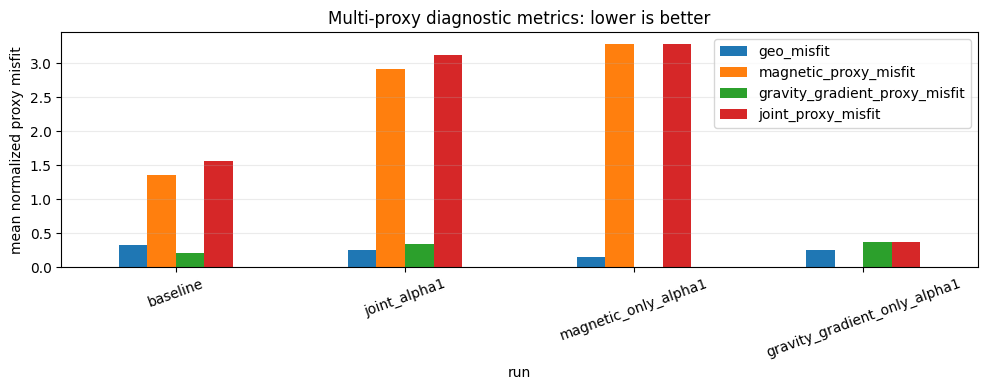

In [13]:
try:
    import matplotlib.pyplot as plt
    metrics_to_plot = ["geo_misfit", "magnetic_proxy_misfit", "gravity_gradient_proxy_misfit", "joint_proxy_misfit"]
    plot_rows = []
    for name, paths in mag_runs.items():
        metrics = read_csv_rows(paths["eval"])
        row = {"run": name}
        for metric in metrics_to_plot:
            row[metric] = mean_value(metrics, metric)
        plot_rows.append(row)
    if pd is not None:
        df = pd.DataFrame(plot_rows).set_index("run")
        ax = df.plot(kind="bar", figsize=(10, 4), rot=20)
        ax.set_ylabel("mean normalized proxy misfit")
        ax.set_title("Multi-proxy diagnostic metrics: lower is better")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()
    else:
        show_table(plot_rows)
except Exception as exc:
    print("plot skipped:", repr(exc))

## 6. Trace 强度检查

这一部分用于确认 alpha=1.0 是否真的进入采样动力学。结果显示 guidance 很强，因此失败不是因为 alpha 太小。

In [14]:
trace_rows = []
for name, paths in mag_runs.items():
    trace = read_csv_rows(paths["trace"])
    last = [row for row in trace if row.get("step") == "31"]
    trace_rows.append({
        "run": name,
        "effective_guidance_ratio_all_mean": fmt(mean_value(trace, "effective_guidance_ratio")),
        "effective_guidance_ratio_last_mean": fmt(mean_value(last, "effective_guidance_ratio")),
        "guidance_velocity_norm_last_mean": fmt(mean_value(last, "guidance_velocity_norm")),
        "geo_loss_last_mean": fmt(mean_value(last, "geo_loss")),
        "magnetic_loss_last_mean": fmt(mean_value(last, "magnetic_loss")),
        "gravity_gradient_loss_last_mean": fmt(mean_value(last, "gravity_gradient_loss")),
    })
show_table(trace_rows)

,run,effective_guidance_ratio_all_mean,effective_guidance_ratio_last_mean,guidance_velocity_norm_last_mean,geo_loss_last_mean,magnetic_loss_last_mean,gravity_gradient_loss_last_mean
0,baseline,0.00000,0.00000,0.00000,1.59803,1.38061,0.21376
1,joint_alpha1,0.24989,0.95877,2236.90562,3.25892,3.04074,0.34921
2,magnetic_only_alpha1,0.24989,0.95877,2236.81134,3.65710,3.65710,NaN
3,gravity_gradient_only_alpha1,0.24989,0.95877,2237.56194,0.36065,NaN,0.36065


## 7. 可选：重新计算 target-label metrics

该单元会导入项目脚本，读取 sample_*.pt 并重新计算 target label 10 的 hard decoded target metrics。运行会比前面几个单元慢一些，但不会触发训练或采样。

In [15]:
import sys

PROJECT = BASE.parent
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

try:
    from geology_io_utils import find_sample_files, load_sample_stack, load_volume
    from evaluate_target_feature import target_metric_records

    truth = load_volume(PROJECT / "samples/jupyter-demo/cond_generation_1/true_model.pt", single=True)
    target_label = 10
    sample_dirs = {
        "baseline": mag_base / "baseline_joint_alpha0",
        "joint_alpha1": mag_base / "guided_joint_alpha0_50",
        "magnetic_only_alpha1": mag_base / "guided_magnetic_alpha1_00",
        "gravity_gradient_only_alpha1": mag_base / "guided_gravity_gradient_alpha1_00",
    }
    target_rows = []
    for name, sample_dir in sample_dirs.items():
        samples, records = load_sample_stack(find_sample_files(sample_dir))
        rows, summary = target_metric_records(samples, truth, target_label, records)
        target_rows.append({
            "run": name,
            "target_iou": fmt(mean_value(rows, "target_iou")),
            "target_precision": fmt(mean_value(rows, "target_precision")),
            "target_recall": fmt(mean_value(rows, "target_recall")),
            "target_f1": fmt(mean_value(rows, "target_f1")),
            "target_volume_error": fmt(mean_value(rows, "target_volume_error")),
            "centroid_distance": fmt(mean_value(rows, "target_centroid_distance")),
            "probability_entropy_mean": fmt(summary.get("probability_entropy_mean")),
        })
    show_table(target_rows)
except Exception as exc:
    print("target metric recomputation skipped or failed:", repr(exc))

,run,target_iou,target_precision,target_recall,target_f1,target_volume_error,centroid_distance,probability_entropy_mean
0,baseline,0.42636,0.53164,0.68161,0.59568,2804.9375,6.94354,0.06443
1,joint_alpha1,0.42611,0.53168,0.68091,0.59543,2790.9375,6.93229,0.06483
2,magnetic_only_alpha1,0.42328,0.52772,0.68006,0.59263,2868.5000,7.10496,0.06587
3,gravity_gradient_only_alpha1,0.42146,0.52488,0.68020,0.59089,2937.7500,7.23051,0.06683


## 8. 为什么 gravity-only 不容易变差，而 magnetic/gradient 变差

主要原因判断：

1. **Gravity-only 的优化目标和评估目标同构。** 采样时和评估时都使用 `density_config + SimpleGravityForward + normalized_misfit`。
2. **Simple gravity-proxy 是平滑低频场。** 少量体素变化就可能降低 field residual，不要求 hard decoded dike 边界非常准确。
3. **Magnetic / gravity-gradient proxy 更局部、更高频。** 当前 kernel 对边界、位置和 target geometry 更敏感，hard decode 少量错误变化会被放大。
4. **soft guidance 与 hard categorical decode 有明显落差。** trace 显示 guidance velocity 很强，但 decoded 体素变化只有约 0.2%-0.4%。
5. **强 susceptibility contrast 可能把连续状态推离 learned geological prior manifold。** target susceptibility=5.0、background scale=0.01，loss landscape 很尖锐。
6. **gravity-gradient-only 破坏 borehole consistency。** 这是强 guidance 破坏条件约束的警告信号。

## 8A. 当前可交付文件索引

下面列出这次工作中最常用的报告、notebook、CSV 和图片入口。

In [16]:
artifact_rows = [
    {"类型": "中文复盘报告", "路径": md_link(BASE / "experiment_development_report_zh.md")},
    {"类型": "展示 notebook", "路径": md_link(BASE / "experiment_development_report_zh.ipynb")},
    {"类型": "英文/简版报告", "路径": md_link(BASE / "experiment_development_report.md")},
    {"类型": "候选筛选表", "路径": md_link(BASE / "candidate_screening/candidate_screening.csv")},
    {"类型": "label9 demo report", "路径": md_link(BASE / "cond_generation_0_label9/final_demo/demo_report.md")},
    {"类型": "label10 demo report", "路径": md_link(BASE / "candidate_screening/cond_generation_1_label10/final_demo/demo_report.md")},
    {"类型": "label7 demo report", "路径": md_link(BASE / "candidate_screening/paper_cond_gen_0_label7/final_demo/demo_report.md")},
    {"类型": "magnetic/joint observed proxy", "路径": md_link(BASE / "magnetic_joint/cond_generation_1_label10/observed_geophysics/manifest.json")},
    {"类型": "multi-proxy baseline metrics", "路径": md_link(BASE / "magnetic_joint/cond_generation_1_label10/baseline_joint_evaluation/metrics.csv")},
    {"类型": "multi-proxy joint metrics", "路径": md_link(BASE / "magnetic_joint/cond_generation_1_label10/guided_joint_evaluation/metrics.csv")},
]
if pd is not None:
    display(HTML(pd.DataFrame(artifact_rows).to_html(escape=False, index=False)))
else:
    show_table(artifact_rows)

类型,路径
中文复盘报告,[experiment_development_report_zh.md](experiment_development_report_zh.md)
展示 notebook,[experiment_development_report_zh.ipynb](experiment_development_report_zh.ipynb)
英文/简版报告,[experiment_development_report.md](experiment_development_report.md)
候选筛选表,[candidate_screening.csv](candidate_screening/candidate_screening.csv)
label9 demo report,[demo_report.md](cond_generation_0_label9/final_demo/demo_report.md)
label10 demo report,[demo_report.md](candidate_screening/cond_generation_1_label10/final_demo/demo_report.md)
label7 demo report,[demo_report.md](candidate_screening/paper_cond_gen_0_label7/final_demo/demo_report.md)
magnetic/joint observed proxy,[manifest.json](magnetic_joint/cond_generation_1_label10/observed_geophysics/manifest.json)
multi-proxy baseline metrics,[metrics.csv](magnetic_joint/cond_generation_1_label10/baseline_joint_evaluation/metrics.csv)
multi-proxy joint metrics,[metrics.csv](magnetic_joint/cond_generation_1_label10/guided_joint_evaluation/metrics.csv)


## 9. 当前建议

暂停继续加 alpha、加权重或换 case 试运气。

如果继续研究，应先补诊断而不是继续跑大实验：

- 记录每个 step 的 `loss_before_step` 和 `loss_after_step`。
- 保存 final continuous state 的 soft target probability volume。
- 对同一个 `x` 做单步 `x - eps * grad` 验证 soft proxy loss 是否真的下降。
- 再 hard decode，检查 hard proxy loss 是否同步下降。
- 做 `tau` 和物性 contrast sweep，而不是继续盲目提高 alpha。

目前更稳妥的论文表述是：gravity-only lightweight proxy guidance 可降低 proxy residual，但 target-level reconstruction improvement is modest。